# 02. Regression homework

Imports

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

Dataset

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


Preparing the dataset

In [ ]:
base = [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]

In [ ]:
def prepare(df):
    df = df.copy()    
    return df[base]

df = prepare(df)
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

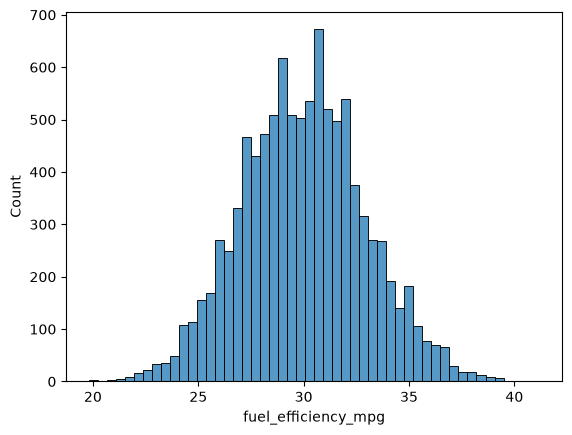

In [31]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

fuel_efficiency_mpg looks normally distributed and has no long tail.

## Question 1

In [32]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Answer: 'horsepower'

## Question 2

In [114]:
df.horsepower.median()

np.float64(254.0)

Anser: 254

---
Prepare and split the dataset

In [34]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [35]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


In [36]:
df_val

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2240,265.0,3990,2004,30.4
1,2390,259.0,4770,2019,32.8
2,2360,265.0,4320,2018,27.8
3,2430,279.0,4430,2008,28.6
4,2220,249.0,4030,1999,31.1
...,...,...,...,...,...
1995,1980,229.0,4140,2020,30.3
1996,2590,263.0,4630,1989,28.7
1997,2390,264.0,4550,2017,30.6
1998,2330,244.0,4440,2014,31.0


In [37]:
df_test

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2370,268.0,4410,1981,27.8
1,2240,256.0,4220,2020,37.3
2,2090,217.0,3910,2023,33.1
3,2280,251.0,4420,2021,31.3
4,2450,256.0,4420,1979,26.4
...,...,...,...,...,...
1995,2100,257.0,4130,1988,30.7
1996,2160,231.0,4180,2000,25.5
1997,2430,246.0,4660,2013,30.1
1998,2450,307.0,4500,2014,30.5


---

## Question 3

In [53]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
]
mean = df_train.horsepower.mean()

In [63]:
def prepare_X_null(df):
    df = df.copy()

    df_num = df[features]
    df_num = df_num.fillna(0)

    X = df_num.values

    return X

X_null = prepare_X_null(df)
X_null

array([[2180.,  243., 3870., 2006.],
       [2390.,  272., 4210., 2008.],
       [2320.,  267., 4240., 1996.],
       ...,
       [2480.,  267., 4590., 2014.],
       [2180.,  270., 4450., 2004.],
       [2380.,  295., 4370., 2011.]], shape=(10000, 4))

In [64]:
def prepare_X_mean(df):
    df = df.copy()

    df_num = df[features]
    df_num = df_num.fillna(mean)

    X = df_num.values

    return X

X_mean = prepare_X_mean(df)
X_mean

array([[2180.,  243., 3870., 2006.],
       [2390.,  272., 4210., 2008.],
       [2320.,  267., 4240., 1996.],
       ...,
       [2480.,  267., 4590., 2014.],
       [2180.,  270., 4450., 2004.],
       [2380.,  295., 4370., 2011.]], shape=(10000, 4))

In [56]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [60]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv @ X.T @ y

    return w_full[0], w_full[1:]

In [59]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error**2
    mse = se.mean()

    return np.sqrt(mse)

With null:

In [69]:
X_training_null = prepare_X_null(df_train)
w0_null, w_null = train_linear_regression(X_training_null, y_train)

X_val_null = prepare_X_null(df_val)
y_pred_null = w0_null + X_val_null @ w_null

np.round(rmse(y_val, y_pred_null), 3)

np.float64(2.205)

With mean:

In [70]:
X_training_mean = prepare_X_mean(df_train)
w0_mean, w_mean = train_linear_regression(X_training_mean, y_train)

X_val_mean = prepare_X_mean(df_val)
y_pred_mean = w0_mean + X_val_mean @ w_mean

np.round(rmse(y_val, y_pred_mean), 3)

np.float64(2.202)

Answer: with mean

## Question 4

In [76]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    XTX += np.eye(XTX.shape[0]) * r
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv @ X.T @ y

    return w_full[0], w_full[1:]

In [84]:
score_dict = {}

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_null(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X_null(df_val)
    y_pred = w0 + X_val @ w

    score = rmse(y_val, y_pred)
    score_dict[r] = score
    
    print(f"Reg: {r:<10}Bias: {w0:<26}Score: {np.round(score, 4):<20}")
    
print(f"Best score: {np.round(min(score_dict.values()), 4)}. R = {[r for r, v in score_dict.items() if v == min(score_dict.values())][0]}")

Reg: 0         Bias: -153.88496188271776       Score: 2.2053              
Reg: 0.01      Bias: -148.30921244167564       Score: 2.2058              
Reg: 0.1       Bias: -111.8387103928938        Score: 2.2241              
Reg: 1         Bias: -32.33186596503115        Score: 2.3492              
Reg: 5         Bias: -7.772852209995103        Score: 2.4094              
Reg: 10        Bias: -3.987116416014508        Score: 2.4195              
Reg: 100       Bias: -0.40821964884641493      Score: 2.4292              
Best score: 2.2053. R = 0


Answer: 0

## Question 5

In [100]:
rmse_dict = {}

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    X_train = prepare_X_null(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X_null(df_val)
    y_pred = w0 + X_val @ w

    score = rmse(y_val, y_pred)
    rmse_dict[seed] = score
    
rmse_arr = np.array(list(rmse_dict.values()))
rmse_arr

array([2.23920414, 2.20211282, 2.16341978, 2.20435888, 2.20188009,
       2.24578515, 2.26972121, 2.1907946 , 2.2166112 , 2.20703659])

In [ ]:
np.std(rmse_arr)

np.float64(0.028781274078154895)

In [102]:
np.std(rmse_arr).round(3)

np.float64(0.029)

Answer: 0.029

## Question 6

In [109]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

y_test = df_test.fuel_efficiency_mpg.values

y_full = np.concat([y_train, y_val])
df_full = pd.concat([df_train, df_val])

In [113]:
X_full = prepare_X_null(df_full)
w0, w = train_linear_regression_reg(X_full, y_full, r=0.001)

X_test = prepare_X_null(df_test)
y_pred = w0 + X_test @ w

rmse(y_test, y_pred)

np.float64(2.2358277471948873)

In [115]:
np.round(rmse(y_test, y_pred), 3)

np.float64(2.236)

Answer: 2.236